# Notebook 06 — SHAP Explainability
**Fin-Guardian AI | Phase 2 | Step 6**

### Why SHAP?
XGBoost scores a transaction at 0.87 fraud probability. That number alone is not enough.
Regulators, customers, and your team need to know WHY.

SHAP answers:
> 'Flagged because: amount is 18x the user average (+0.42), recipient is new (+0.31), balance zeroed (+0.19)'

### What SHAP produces
- The base rate (average fraud rate)
- Each feature's contribution toward fraud or legitimate
- Top 3 reasons in plain English → goes into API response
- Saved as shap_top_features in InferenceResult schema


In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print(f'SHAP version    : {shap.__version__}')
print(f'XGBoost version : {xgb.__version__}')
print('All imports done.')


c:\Users\rohan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version    : 0.52.0
XGBoost version : 3.2.0
All imports done.


In [2]:
# Cell 2 — Load Model and Data
with open('../artifacts/feature_list.json') as f:
    meta = json.load(f)
FEATURES = meta['features']
TARGET   = meta['target']

model = xgb.XGBClassifier()
model.load_model('../artifacts/xgboost_fraud.json')
print('XGBoost model loaded.')

df_val = pd.read_csv('../artifacts/val.csv')
X_val  = df_val[FEATURES]
y_val  = df_val[TARGET]

# Use a sample — SHAP on 415k rows would take hours
SAMPLE_SIZE = 5000
df_sample   = df_val.sample(n=SAMPLE_SIZE, random_state=42)
X_sample    = df_sample[FEATURES]
y_sample    = df_sample[TARGET]

print(f'Val set         : {len(df_val):,} rows')
print(f'Sample for SHAP : {len(X_sample):,} rows')
print(f'Fraud in sample : {y_sample.sum()}')


XGBoost model loaded.
Val set         : 415,561 rows
Sample for SHAP : 5,000 rows
Fraud in sample : 6


In [3]:
# Cell 3 — Create SHAP Explainer
# TreeExplainer is the fastest SHAP method for tree models.
# It uses an exact algorithm designed for XGBoost/LightGBM.
# shap_values shape: (n_samples, n_features)
# Positive value = feature pushed prediction toward fraud
# Negative value = feature pushed prediction toward legitimate

print('Computing SHAP values — takes about 30-60 seconds...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values shape : {shap_values.shape}')
print(f'Samples explained : {shap_values.shape[0]}')
print(f'Features          : {shap_values.shape[1]}')


Computing SHAP values — takes about 30-60 seconds...
SHAP values shape : (5000, 16)
Samples explained : 5000
Features          : 16


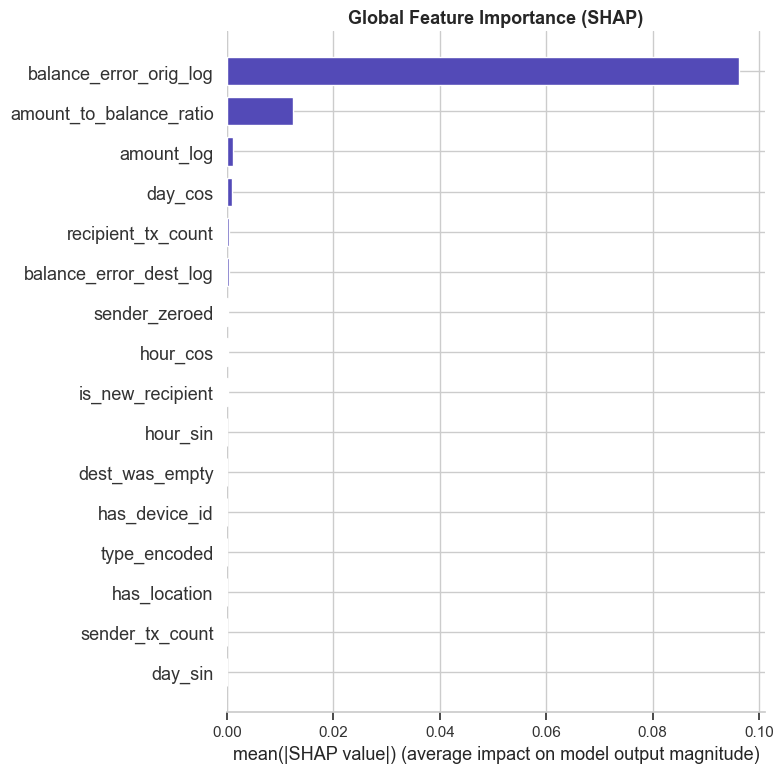

Chart saved to artifacts/shap_feature_importance.png


In [4]:
# Cell 4 — Global Feature Importance Bar Chart
# SHAP importance = how much each feature ACTUALLY impacts predictions.
# More honest than XGBoost built-in importance.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    plot_type='bar',
    feature_names=FEATURES,
    show=False,
    color='#534AB7'
)
plt.title('Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/shap_feature_importance.png')


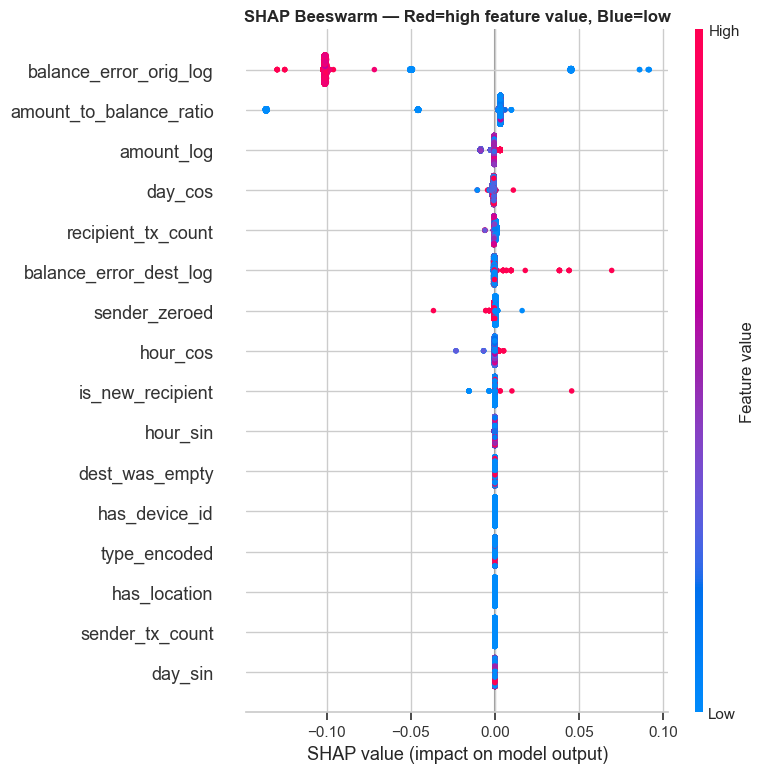

In [5]:
# Cell 5 — SHAP Beeswarm Plot
# Each dot = one transaction
# X axis = SHAP value (impact on prediction)
# Colour = feature value (red=high, blue=low)
# Red dots on RIGHT = high value pushes toward fraud

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=FEATURES,
    show=False, max_display=16
)
plt.title('SHAP Beeswarm — Red=high feature value, Blue=low', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Cell 6 — Explain a Single Fraud Transaction
# This simulates what happens in production for every HOLD/DENY.
# The output becomes shap_top_features in InferenceResult schema.

fraud_rows = df_sample[df_sample[TARGET] == 1]

if len(fraud_rows) > 0:
    fraud_pos   = df_sample.index.get_loc(fraud_rows.index[0])
    transaction = X_sample.iloc[fraud_pos]
    shap_for_tx = shap_values[fraud_pos]
    fraud_prob  = model.predict_proba(transaction.values.reshape(1, -1))[0][1]

    explanation = pd.DataFrame({
        'feature'    : FEATURES,
        'value'      : transaction.values,
        'shap_impact': shap_for_tx,
    }).sort_values('shap_impact', ascending=False)

    print(f'Fraud probability : {fraud_prob:.4f}')
    print(f'Base rate         : {explainer.expected_value:.4f}')
    print()
    print(f'{"Feature":35s} {"Value":>10} {"SHAP Impact":>12}')
    print('-' * 60)
    for _, row in explanation.iterrows():
        direction = 'FRAUD' if row['shap_impact'] > 0 else 'legit'
        print(f"{row['feature']:35s} {row['value']:>10.4f} {row['shap_impact']:>+12.4f}  {direction}")

    top3 = explanation.head(3)
    top3_list = [
        {'feature': r['feature'], 'value': round(float(r['value']),4), 'impact': round(float(r['shap_impact']),4)}
        for _, r in top3.iterrows()
    ]
    print()
    print('TOP 3 REASONS (goes into API response):')
    print(json.dumps(top3_list, indent=2))
else:
    print('No fraud in sample — increase SAMPLE_SIZE or change random_state')
    fraud_pos, transaction, fraud_prob, top3_list = None, None, None, []


Fraud probability : 0.5250
Base rate         : -0.0002

Feature                                  Value  SHAP Impact
------------------------------------------------------------
balance_error_orig_log                  0.0000      +0.0860  FRAUD
amount_to_balance_ratio                 1.0000      +0.0098  FRAUD
balance_error_dest_log                 13.5537      +0.0068  FRAUD
is_new_recipient                        1.0000      +0.0031  FRAUD
recipient_tx_count                      0.0000      +0.0002  FRAUD
day_cos                                -1.0000      +0.0002  FRAUD
hour_sin                                1.0000      +0.0001  FRAUD
day_sin                                 0.0000      +0.0000  legit
sender_tx_count                         0.0000      +0.0000  legit
has_device_id                           0.0000      +0.0000  legit
has_location                            0.0000      +0.0000  legit
dest_was_empty                          1.0000      +0.0000  legit
type_encoded       

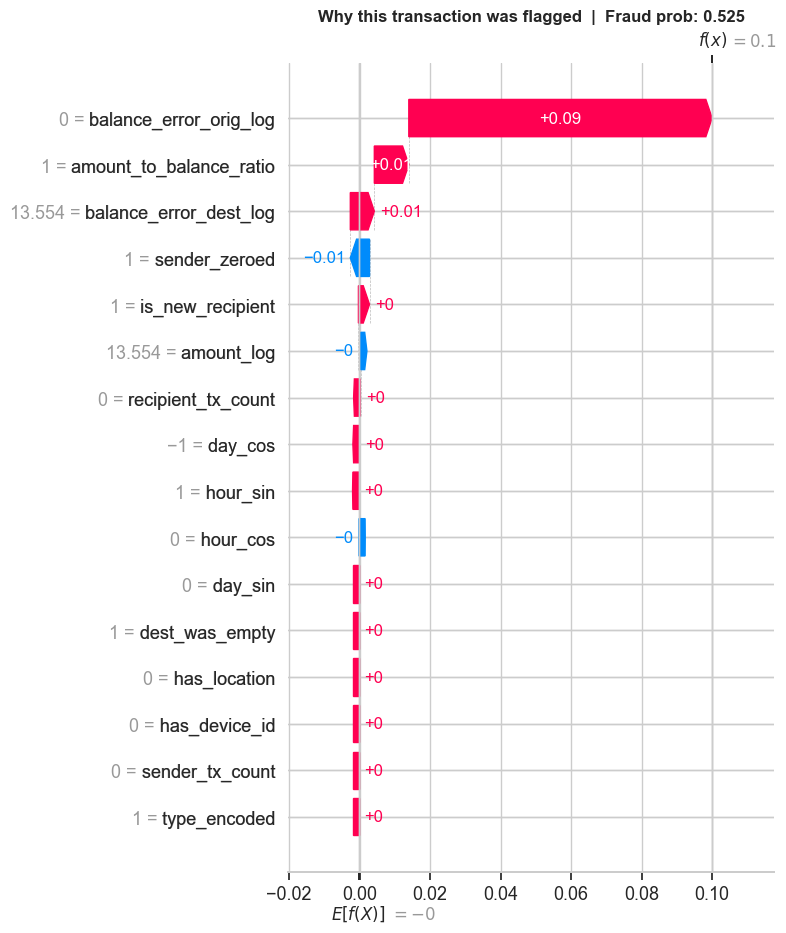

Waterfall chart saved to artifacts/shap_waterfall_fraud.png


In [7]:
# Cell 7 — Waterfall Plot (single transaction)
# Shows how we get from base rate to final prediction step by step.
# Like a bridge: each feature adds or subtracts from the base rate.

if fraud_pos is not None and transaction is not None:
    shap_explanation = shap.Explanation(
        values        = shap_values[fraud_pos],
        base_values   = explainer.expected_value,
        data          = transaction.values,
        feature_names = FEATURES,
    )
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(shap_explanation, show=False, max_display=16)
    plt.title(f'Why this transaction was flagged  |  Fraud prob: {fraud_prob:.3f}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../artifacts/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Waterfall chart saved to artifacts/shap_waterfall_fraud.png')
else:
    print('No fraud transaction available for waterfall plot.')


In [8]:
# Cell 8 — Production SHAP Function
# This exact function runs inside FastAPI for every HOLD/DENY decision.

def get_shap_explanation(model, explainer, feature_values, feature_names, top_n=3):
    shap_vals = explainer.shap_values(feature_values.reshape(1, -1))[0]
    ranked = sorted(
        zip(feature_names, feature_values.flatten(), shap_vals),
        key=lambda x: abs(x[2]),
        reverse=True
    )
    return [
        {'feature': f, 'value': round(float(v), 4), 'impact': round(float(i), 4)}
        for f, v, i in ranked[:top_n]
    ]

# Test it
if transaction is not None:
    result = get_shap_explanation(model, explainer, transaction.values, FEATURES)
    print('Production function output:')
    print(json.dumps(result, indent=2))
    print()
    print('This JSON goes into InferenceResult.shap_top_features')


Production function output:
[
  {
    "feature": "balance_error_orig_log",
    "value": 0.0,
    "impact": 0.086
  },
  {
    "feature": "amount_to_balance_ratio",
    "value": 1.0,
    "impact": 0.0098
  },
  {
    "feature": "balance_error_dest_log",
    "value": 13.5537,
    "impact": 0.0068
  }
]

This JSON goes into InferenceResult.shap_top_features


In [9]:
# Cell 9 — Save SHAP Explainer for Production
explainer_path = '../artifacts/shap_explainer.pkl'
with open(explainer_path, 'wb') as f:
    pickle.dump(explainer, f)

# Save production utility function
func_lines = [
    'import numpy as np\n',
    'import pickle\n',
    '\n',
    'def get_shap_explanation(model, explainer, feature_values, feature_names, top_n=3):\n',
    '    shap_vals = explainer.shap_values(feature_values.reshape(1, -1))[0]\n',
    '    ranked = sorted(zip(feature_names, feature_values.flatten(), shap_vals),\n',
    '                    key=lambda x: abs(x[2]), reverse=True)\n',
    '    return [{"feature": f, "value": round(float(v),4), "impact": round(float(i),4)}\n',
    '            for f, v, i in ranked[:top_n]]\n',
]
with open('../artifacts/shap_utils.py', 'w') as f:
    f.writelines(func_lines)

print(f'SHAP explainer saved : {explainer_path}')
print(f'SHAP utils saved     : artifacts/shap_utils.py')
print()
print('Files in artifacts/:')
for fname in sorted(os.listdir('../artifacts')):
    size = os.path.getsize(f'../artifacts/{fname}') / 1e3
    print(f'  {fname:40s} {size:>8.1f} KB')
print()
print('=' * 60)
print('NOTEBOOK 06 COMPLETE')
print('=' * 60)
print('SHAP explainer  : artifacts/shap_explainer.pkl')
print('Feature chart   : artifacts/shap_feature_importance.png')
print('Waterfall chart : artifacts/shap_waterfall_fraud.png')
print('Production func : artifacts/shap_utils.py')
print('=' * 60)
print()
print('PHASE 2 DATA SCIENCE PIPELINE COMPLETE')
print()
print('Artifacts ready for Phase 3 — FastAPI Gateway:')
print('  xgboost_fraud.onnx      — hot path classifier')
print('  autoencoder_best.pt     — anomaly detector')
print('  shap_explainer.pkl      — explainability engine')
print('  feature_scaler.pkl      — feature normaliser')
print('  feature_list.json       — feature contract')
print('  model_metadata.json     — thresholds and config')
print()
print('Next: Phase 3 — FastAPI Gateway serving real-time predictions')


SHAP explainer saved : ../artifacts/shap_explainer.pkl
SHAP utils saved     : artifacts/shap_utils.py

Files in artifacts/:
  autoencoder_best.pt                          13.5 KB
  autoencoder_full.pt                          15.4 KB
  autoencoder_metadata.json                     0.6 KB
  feature_list.json                             0.4 KB
  feature_scaler.pkl                            1.2 KB
  model_metadata.json                           0.6 KB
  shap_beeswarm.png                           110.1 KB
  shap_explainer.pkl                          227.9 KB
  shap_feature_importance.png                  82.5 KB
  shap_utils.py                                 0.5 KB
  shap_waterfall_fraud.png                    114.8 KB
  test.csv                                  74772.2 KB
  train.csv                                345424.8 KB
  val.csv                                   74407.4 KB
  xgboost_fraud.json                          101.2 KB
  xgboost_fraud.onnx                           73.4

In [1]:
import os, json

print("=== ARTIFACTS CHECK ===")
for f in sorted(os.listdir('../artifacts')):
    size = os.path.getsize(f'../artifacts/{f}') / 1e3
    print(f"  {f:40s} {size:>8.1f} KB")

print()
print("=== MODEL METADATA ===")
with open('../artifacts/model_metadata.json') as f:
    meta = json.load(f)
for k, v in meta.items():
    if k != 'features':
        print(f"  {k:25s}: {v}")

=== ARTIFACTS CHECK ===
  autoencoder_best.pt                          13.5 KB
  autoencoder_full.pt                          15.4 KB
  autoencoder_metadata.json                     0.6 KB
  feature_list.json                             0.4 KB
  feature_scaler.pkl                            1.2 KB
  model_metadata.json                           0.6 KB
  shap_beeswarm.png                           110.1 KB
  shap_explainer.pkl                          227.9 KB
  shap_feature_importance.png                  82.5 KB
  shap_utils.py                                 0.5 KB
  shap_waterfall_fraud.png                    114.8 KB
  test.csv                                  74772.2 KB
  train.csv                                345424.8 KB
  val.csv                                   74407.4 KB
  xgboost_fraud.json                          101.2 KB
  xgboost_fraud.onnx                           73.4 KB

=== MODEL METADATA ===
  target                   : isFraud
  n_features               : 16
  b